## GP-Based IBM Construction
Fits frequentist GP vital rates to the baseline data. Constructs IPM (using the posterior predictive y mean -- $\mathbb{E}[y'\mid y]$, $y'$ are the meshpoints, $y$ are the training observations) and calculates population statistics. and generates an IBM sample data. IBM is done with an initial population of 500 and over 5 years.

<mark>[Updated from v2. This notebook uses the ~~predictive mean provided by GPFlow .predict_y method~~ .predict_f_samples method which samples a GP. The IBMs are improved on from GP_IBM by using exact GP predictions during each year of simulation, instead of evaluating on a dense grid and interpolating linearly. This previously also meant that the GP is extrapolated linearly during IBM when sizes exceeded the grid on which the true predictive GP was evaluated at, which is incorrect.]</mark>



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gpflow as gp
import tensorflow as tf
from scipy.stats import norm
from ipm_utils import (
    sample_f,
    make_gp_ipm
)

In [2]:
sim_data = pd.read_csv("baseline_ibm_data_1000.csv")

In [3]:
sim_data.head()

,z,Repr,Seeds,Surv,z1,age,alive,yr
0,0.510920,0,NaN,1.0,1.446648,0,True,45
1,1.770340,0,NaN,1.0,1.622350,3,True,62
2,0.587524,0,NaN,1.0,2.585566,0,True,76
3,-0.109235,0,NaN,0.0,NaN,0,False,75
4,0.120598,0,NaN,0.0,NaN,0,False,88


In [4]:
sim_data.describe()

,z,Repr,Seeds,Surv,z1,age,yr
count,1000.000000,1000.000000,30.000000,970.000000,418.000000,1000.000000,1000.000000
mean,0.482066,0.030000,2335.233333,0.430928,1.457030,0.747000,72.836000
std,1.070879,0.170673,2073.777541,0.495462,0.819888,1.273032,17.037705
min,-2.838371,0.000000,274.000000,0.000000,-0.570366,0.000000,1.000000
25%,-0.279494,0.000000,970.250000,0.000000,0.852123,0.000000,65.000000
50%,0.406070,0.000000,1778.000000,0.000000,1.453693,0.000000,79.000000
75%,1.243246,0.000000,2827.250000,1.000000,2.032793,1.000000,86.000000
max,3.695600,1.000000,9178.000000,1.000000,3.700061,7.000000,90.000000


In [5]:
print(f"Smallest log(size): {sim_data['z'].min()}")
print(f"Largest log(size): {sim_data['z'].max()}")

Smallest log(size): -2.838371359491444
Largest log(size): 3.695600483842302


In [6]:
# Since the log(size) has range [-2.48, 3.89], we will use a range of [-3,4] 
# NOTE: We need to check this for Eviction later on 
L = -3
U = 4.5

# Growth

In [7]:
# Growth kernel (not including new recruits - for new recruits, z1 = NaN)
growth = sim_data.loc[
    (sim_data["Repr"] == 0) &
    (sim_data["Surv"] == 1),
    ["z", "z1"],
].dropna()

X_growth = growth["z"].to_numpy().reshape(-1, 1).astype(np.float64)
Y_growth = growth["z1"].to_numpy().reshape(-1, 1).astype(np.float64)

In [8]:
print(X_growth.shape)
print(Y_growth.shape)

(418, 1)
(418, 1)


In [9]:
kernel_growth = gp.kernels.SquaredExponential()

In [10]:
model_growth = gp.models.GPR(data = (X_growth,Y_growth), kernel = kernel_growth)

In [11]:
optimizer = gp.optimizers.Scipy()
optimizer.minimize(model_growth.training_loss, model_growth.trainable_variables)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 420.31957568509847
        x: [ 8.678e+00  1.071e+01 -6.430e-01]
      nit: 21
      jac: [ 3.511e-05 -1.819e-05 -8.013e-05]
     nfev: 25
     njev: 25
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

In [12]:
print("Variance:")
print(model_growth.kernel.variance.numpy())
print("Lengthscale:")
print(model_growth.kernel.lengthscales.numpy())
print("Noise variance:")
print(model_growth.likelihood.variance.numpy())
growth_noise_var = model_growth.likelihood.variance.numpy()

Variance:
10.7071977635513
Lengthscale:
8.677906756303448
Noise variance:
0.4224773443977135


In [ ]:
param_dict = {}
param_dict["growth_var"] = model_growth.kernel.variance.numpy()
param_dict["growth_ls"] = model_growth.kernel.lengthscales.numpy()
param_dict["growth_noise"] = model_growth.likelihood.variance.numpy()

In [17]:
X_grid = np.linspace(
    L,
    U,
    500,
).reshape(-1,1)

In [18]:
mean, var = model_growth.predict_y(X_grid)
var = var.numpy().squeeze()
mean = mean.numpy().squeeze()

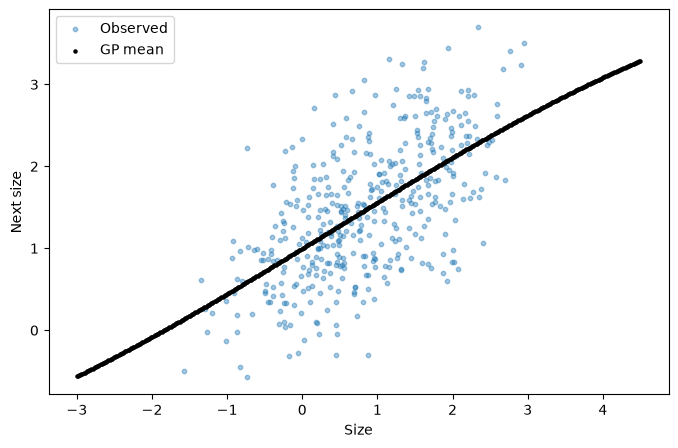

In [19]:
plt.figure(figsize=(8,5))

plt.scatter(
    X_growth,
    Y_growth,
    s=10,
    alpha=0.4,
    label="Observed",
)

plt.scatter(
    X_grid,
    mean,
    color="black",
    s=5,
    label="GP mean",
)

plt.xlabel("Size")
plt.ylabel("Next size")
plt.legend()
plt.show()

# Survival

In [20]:
surv = sim_data.loc[sim_data["Surv"].notna(), ["z", "Surv"]].copy()

X_surv = surv["z"].to_numpy().reshape(-1, 1).astype(np.float64)
Y_surv = surv["Surv"].to_numpy().reshape(-1, 1).astype(np.float64)

print(X_surv.shape)
print(Y_surv.shape)

(970, 1)
(970, 1)


In [21]:
kernel_surv  = gp.kernels.SquaredExponential()

In [22]:
model_surv = gp.models.VGP(data=(X_surv, Y_surv), kernel=kernel_surv, likelihood=gp.likelihoods.Bernoulli(invlink = tf.sigmoid))

In [23]:
optimizer = gp.optimizers.Scipy()

optimizer.minimize(model_surv.training_loss, variables = model_surv.trainable_variables)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 600.6474221742826
        x: [-5.131e-02  1.007e+00 ...  3.767e+00  7.079e+00]
      nit: 157
      jac: [-1.476e-02  2.539e-04 ... -2.042e-03  2.877e-03]
     nfev: 173
     njev: 173
 hess_inv: <471907x471907 LbfgsInvHessProduct with dtype=float64>

In [ ]:
param_dict["surv_var"] = model_surv.kernel.variance.numpy()
param_dict["surv_ls"] = model_surv.kernel.lengthscales.numpy()


In [25]:
mean_surv, var_surv = model_surv.predict_y(X_grid)
mean_surv = mean_surv.numpy().squeeze()   
var_surv = var_surv.numpy().squeeze() 

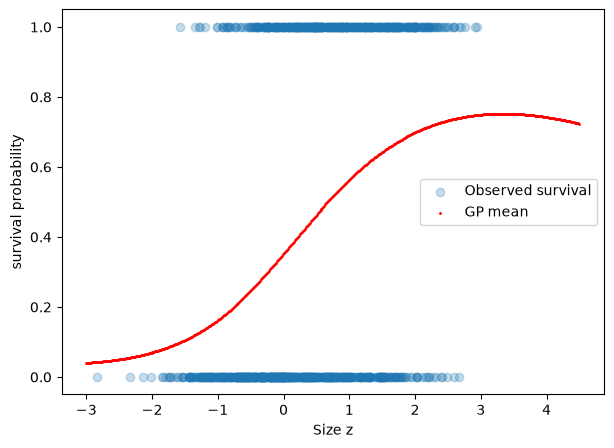

In [26]:
plt.figure(figsize=(7, 5))

plt.scatter(
    X_surv.squeeze(),
    Y_surv.squeeze(),
    alpha=0.25,
    label="Observed survival"
)

plt.scatter(
    X_grid,
    mean_surv,
    color="red",
    s=1,
    label="GP mean",
)

plt.xlabel("Size z")
plt.ylabel("survival probability")
plt.legend()
plt.show()

# Reproduction
$R \sim \mathrm{Bernoulli}(p_{\mathrm{repr}}(z))$

$p_{\mathrm{repr}}(z) = \sigma(f_{\mathrm{repr}}(z))$

$f_{\mathrm{repr}}(z) \sim GP(m(z), k(z,z'))$

In [27]:
# Reproduction / flowering data
repr_data = sim_data.loc[
    sim_data["Repr"].notna(),
    ["z", "Repr"]
].copy()

X_repr = repr_data["z"].to_numpy().reshape(-1, 1).astype(np.float64)
Y_repr = repr_data["Repr"].to_numpy().reshape(-1, 1).astype(np.float64)

print(X_repr.shape)
print(Y_repr.shape)
print(Y_repr.sum())

kernel_repr = gp.kernels.SquaredExponential()

# Bernoulli GP with logistic/sigmoid link
model_repr = gp.models.VGP(data=(X_repr, Y_repr), kernel=kernel_repr, likelihood=gp.likelihoods.Bernoulli(invlink=tf.sigmoid),)
optimizer = gp.optimizers.Scipy()
optimizer.minimize(model_repr.training_loss, variables=model_repr.trainable_variables,)

(1000, 1)
(1000, 1)
30.0


  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 36.00036724558244
        x: [-9.609e-01  1.349e+00 ...  3.460e+00  1.967e+02]
      nit: 148
      jac: [ 9.303e-02 -4.918e-02 ... -9.081e-03 -1.014e-03]
     nfev: 157
     njev: 157
 hess_inv: <501502x501502 LbfgsInvHessProduct with dtype=float64>

In [ ]:
param_dict["repr_var"] = model_repr.kernel.variance.numpy()
param_dict["repr_ls"] = model_repr.kernel.lengthscales.numpy()

In [29]:
# Predict latent GP over grid
mean_repr, cov_repr = model_repr.predict_y(X_grid)

mean_repr = mean_repr.numpy().squeeze()
cov_repr = cov_repr.numpy().squeeze()

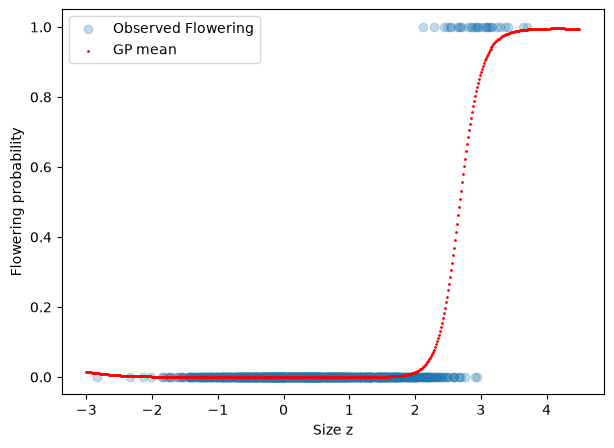

In [30]:
plt.figure(figsize=(7, 5))

plt.scatter(
    X_repr.squeeze(),
    Y_repr.squeeze(),
    alpha=0.25,
    label="Observed Flowering"
)

plt.scatter(
    X_grid,
    mean_repr,
    color="red",
    s=1,
    label="GP mean",
)

plt.xlabel("Size z")
plt.ylabel("Flowering probability")
plt.legend()
plt.show()

# Seed Production
$Seeds \sim \mathrm{Poisson}(\lambda(z))$

$\lambda(z) = \exp(f_{\mathrm{seed}}(z))$

$f_{\mathrm{seed}}(z) \sim GP(m(z), k(z,z'))$

In [32]:
# Seed production data
seed_data = sim_data.loc[
    sim_data["Seeds"].notna(),
    ["z", "Seeds"]
].copy()

X_seed = seed_data["z"].to_numpy().reshape(-1, 1).astype(np.float64)
Y_seed = seed_data["Seeds"].to_numpy().reshape(-1, 1).astype(np.float64)

print(X_seed.shape)
print(Y_seed.shape)

kernel_seed = gp.kernels.SquaredExponential()

# Poisson GP with log link
model_seed = gp.models.VGP(data=(X_seed, Y_seed), kernel=kernel_seed, likelihood=gp.likelihoods.Poisson(),)
optimizer = gp.optimizers.Scipy()

optimizer.minimize(model_seed.training_loss, variables=model_seed.trainable_variables,)

(30, 1)
(30, 1)


  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 164.45451456711396
        x: [ 9.476e-01 -2.075e+00 ...  7.382e+00  6.275e+01]
      nit: 4033
      jac: [ 1.743e-01 -1.499e-01 ...  5.583e-02 -1.500e-02]
     nfev: 4576
     njev: 4576
 hess_inv: <497x497 LbfgsInvHessProduct with dtype=float64>

In [ ]:
param_dict["seed_var"] = model_seed.kernel.variance.numpy()
param_dict["seed_ls"] = model_seed.kernel.lengthscales.numpy()

In [34]:
# Predict latent GP over grid
mean_seed, cov_seed = model_seed.predict_y(X_grid)

mean_seed = mean_seed.numpy().squeeze()
cov_seed = cov_seed.numpy().squeeze()

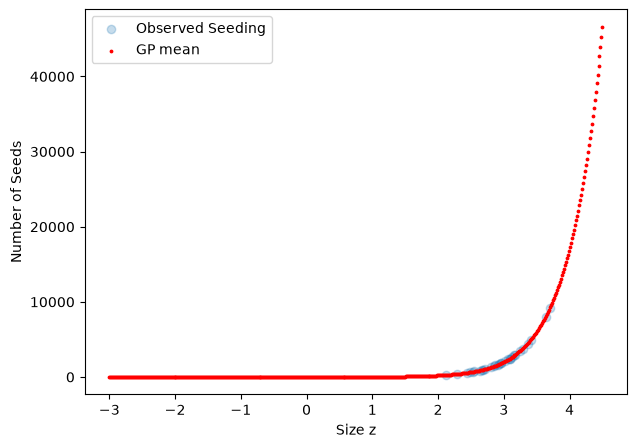

In [35]:
plt.figure(figsize=(7, 5))

plt.scatter(
    X_seed.squeeze(),
    Y_seed.squeeze(),
    alpha=0.25,
    label="Observed Seeding"
)

plt.scatter(
    X_grid.squeeze(),
    mean_seed,
    color="red",
    s=3,
    label="GP mean",
)

plt.xlabel("Size z")
plt.ylabel("Number of Seeds")
plt.legend()
plt.show()

# Recruitment

In [63]:
recruit_data = sim_data[sim_data["age"] == 0].copy()

recruit_mean_est = recruit_data["z"].mean()
recruit_sd_est = recruit_data["z"].std(ddof=1)

n_recruits = (sim_data["age"] == 0).sum()
total_seeds = np.nansum(sim_data["Seeds"])

prob_recruit_est = n_recruits / total_seeds

print(f"recruit_mean: {recruit_mean_est}")
print(f"recruit_sd: {recruit_sd_est}")
print(f"prob_recruit: {prob_recruit_est}")

param_dict['recruit_mean'] = recruit_mean_est
param_dict['recruit_sd'] = recruit_sd_est
param_dict['prob_recruit'] = prob_recruit_est



"""
recruit size
rcsz.int  =   -.08, 
rcsz.sd   =   0.76,
p.r       =   0.007
"""

recruit_mean: -0.08122094407670358
recruit_sd: 0.7558511996617439
prob_recruit: 0.008878484662489116


'\nrecruit size\nrcsz.int  =   -.08, \nrcsz.sd   =   0.76,\np.r       =   0.007\n'

In [ ]:
n_init = 250
SIM_SEED = 562

rng = np.random.default_rng(SIM_SEED)
tf.random.set_seed(SIM_SEED)

# Initial population: random recruits, age 0
pop_df = pd.DataFrame({
    "z": rng.normal(loc=recruit_mean_est, scale=recruit_sd_est, size=n_init),
    "age": np.zeros(n_init, dtype=int),
})

next_id = n_init
records = []
n_years = 6
year = 1 

while (year != n_years) and (len(pop_df) < 5000):
#for year in range(1, n_years + 1):

    # Current population
    z = pop_df["z"].to_numpy()
    age = pop_df["age"].to_numpy()
    n = len(pop_df)
    print(f"Year {year}:Current Population Size = {n}")

    # Flowering
    p_repr = tf.math.sigmoid(sample_f(model_repr, z))
    p_repr = np.clip(p_repr, 0.0, 1.0)
    reproduced = rng.binomial(n=1, p=p_repr).astype(int)

    # Seeds
    n_seeds = np.full(n, np.nan)
    flower_idx = reproduced == 1
    if np.any(flower_idx):
        lam_seed = tf.math.exp(sample_f(model_seed, z[flower_idx]))
        lam_seed = np.clip(lam_seed, 0.0, None)
        n_seeds[flower_idx] = rng.poisson(lam_seed)

    # Survival
    survived = np.full(n, np.nan)
    nonflower_idx = reproduced == 0
    if np.any(nonflower_idx):
        p_surv = tf.math.sigmoid(sample_f(model_surv, z[nonflower_idx]))
        p_surv = np.clip(p_surv, 0.0, 1.0)
        survived_nf = rng.binomial(n=1, p=p_surv).astype(int)
        survived[nonflower_idx] = survived_nf

    z1 = np.full(n, np.nan)
    keep_idx = (reproduced == 0) & (survived == 1)
    z_surv = z[keep_idx]
    age_surv = age[keep_idx] + 1

    # Growth for survivors
    growth_mean = sample_f(model_growth, z_surv)
    z_grown = growth_mean + np.sqrt(growth_noise_var) * rng.normal(size=z_surv.shape)
    z1[keep_idx] = z_grown

    # Store the current year's population record
    year_df = pd.DataFrame({
        "z": z,
        "Repr": reproduced,
        "Seeds": n_seeds,
        "Surv": survived,
        "z1": z1,
        "age": age,
        "alive": keep_idx,
        "yr": year,

    })
    records.append(year_df)

    # Total seeds and number of recruits
    total_seeds = int(np.nansum(n_seeds))
    n_recruits = rng.binomial(n=total_seeds, p=prob_recruit_est)

    # Recruit sizes, age 0
    recruits_z = rng.normal(loc=recruit_mean_est, scale=recruit_sd_est, size=n_recruits,)
    recruits_age = np.zeros(n_recruits, dtype=int)

    # Next year's population
    pop_df = pd.DataFrame({
        "z": np.concatenate([z_grown, recruits_z]),
        "age": np.concatenate([age_surv, recruits_age]),
    })
    year += 1 

sim_df = pd.concat(records, ignore_index=True)


Year 1:Current Population Size = 250
Year 2:Current Population Size = 91
Year 3:Current Population Size = 57
Year 4:Current Population Size = 139
Year 5:Current Population Size = 212


In [56]:
sim_df.head()

,z,Repr,Seeds,Surv,z1,age,alive,yr
0,-0.330,0,NaN,0.000,NaN,0,False,1
1,-1.394,0,NaN,0.000,NaN,0,False,1
2,0.033,0,NaN,1.000,0.689,0,True,1
3,-0.353,0,NaN,0.000,NaN,0,False,1
4,-0.120,0,NaN,1.000,-0.084,0,True,1


In [43]:
pd.set_option("display.float_format", "{:.3f}".format)
sim_df.describe()

,z,Repr,Seeds,Surv,z1,age,yr
count,3083.000,3083.000,86.000,2997.000,1304.000,3083.000,3083.000
mean,0.507,0.028,2096.686,0.435,1.459,0.680,5.452
std,1.058,0.165,2094.976,0.496,0.806,1.123,2.964
min,-2.443,0.000,182.000,0.000,-1.219,0.000,1.000
25%,-0.260,0.000,970.500,0.000,0.936,0.000,3.000
50%,0.422,0.000,1638.000,0.000,1.457,0.000,5.000
75%,1.242,0.000,2433.250,1.000,1.998,1.000,8.000
max,3.912,1.000,14286.000,1.000,3.912,9.000,10.000


In [64]:
param_dict

{'growth_variance': array(10.70719776),
 'growth_lengthscale': array(8.67790676),
 'growth_noise_variance': array(0.42247734),
 'surv_variance': array(7.0794236),
 'surv_lengthscale': array(3.7897362),
 'repr_variance': array(196.6655213),
 'repr_lengthscale': array(3.49090001),
 'seed_variance': array(62.75224282),
 'seed_lengthscale': array(7.38219554),
 'recruit_mean': -0.08122094407670358,
 'recruit_sd': 0.7558511996617439,
 'prob_recruit': 0.008878484662489116}

In [65]:
funcs = {
    'growth': model_growth,
    'surv': model_surv,
    'repr': model_repr,
    'seed': model_seed
}

In [ ]:
gp_ipm = make_gp_ipm(n_mesh_points=250, lower_size=-2.5, upper_size=4.0, params=param_dict, funcs=funcs, correction=True)

In [61]:
eigenvalues, eigenvectors = np.linalg.eig(gp_ipm["K"])

dominant_index = np.argmax(eigenvalues.real)
lambda_gp = eigenvalues[dominant_index].real

stable_distribution = eigenvectors[:, dominant_index].real
stable_distribution = np.abs(stable_distribution)
stable_distribution = stable_distribution / stable_distribution.sum()

mean_stable_size = np.sum(
    stable_distribution
    * gp_ipm["mesh_points"]
)

print(f"GP IPM lambda: {lambda_gp:.4f}")
print(f"Mean stable size: {mean_stable_size:.4f}")

GP IPM lambda: 1.0766
Mean stable size: 0.5340


In [62]:
# Eviction of new recruits
non_evicted_recr = norm.cdf(4, recruit_mean_est, recruit_sd_est) - norm.cdf(-2.5, recruit_mean_est, recruit_sd_est)
non_evicted_recr

0.9993130027930656

In [59]:
sim_df.to_csv('gp_ibm_dataset.csv', index=False)